In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
# Read and merge all CSV files
dfs = []
for filename in os.listdir('data/'):
    file_path = os.path.join('data/', filename)
    print(f"Reading {filename}...")
    df = pd.read_csv(file_path)
    dfs.append(df)
    print(f"  - Shape: {df.shape}")

Reading 202501-divvy-tripdata.csv...
  - Shape: (138689, 13)
Reading 202502-divvy-tripdata.csv...
  - Shape: (151880, 13)
Reading 202503-divvy-tripdata.csv...
  - Shape: (298155, 13)
Reading 202504-divvy-tripdata.csv...
  - Shape: (371341, 13)
Reading 202505-divvy-tripdata.csv...
  - Shape: (502456, 13)
Reading 202506-divvy-tripdata.csv...
  - Shape: (678904, 13)
Reading 202507-divvy-tripdata.csv...
  - Shape: (763432, 13)
Reading 202508-divvy-tripdata.csv...
  - Shape: (790177, 13)
Reading 202509-divvy-tripdata.csv...
  - Shape: (714759, 13)
Reading 202510-divvy-tripdata.csv...
  - Shape: (646039, 13)
Reading 202511-divvy-tripdata.csv...
  - Shape: (356628, 13)
Reading 202512-divvy-tripdata.csv...
  - Shape: (140534, 13)


In [3]:
# Concatenate all dataframes
merged_df = pd.concat(dfs, ignore_index=True)

# Convert date columns to datetime
merged_df['started_at'] = pd.to_datetime(merged_df['started_at'])
merged_df['ended_at'] = pd.to_datetime(merged_df['ended_at'])

In [4]:
# Localize to America/Chicago timezone and convert to UTC to handle DST properly
merged_df['started_at'] = merged_df['started_at'].dt.tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward').dt.tz_convert('UTC')
merged_df['ended_at'] = merged_df['ended_at'].dt.tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward').dt.tz_convert('UTC')

In [5]:
# Calculate duration in minutes
merged_df['duration_minutes'] = (merged_df['ended_at'] - merged_df['started_at']).dt.total_seconds() / 60

In [6]:
# Calculate average duration
avg_duration = merged_df['duration_minutes'].mean()
print(f"\n--- Duration Statistics ---")
print(f"Average duration: {avg_duration:.2f} minutes")
print(f"Min duration: {merged_df['duration_minutes'].min():.6f} minutes")
print(f"Max duration: {merged_df['duration_minutes'].max():.2f} minutes")
print(f"Median duration: {merged_df['duration_minutes'].median():.2f} minutes")
print("\nData is ready for analysis in the dataframe 'merged_df'")


--- Duration Statistics ---
Average duration: 16.03 minutes
Min duration: 0.000767 minutes
Max duration: 1574.90 minutes
Median duration: 9.43 minutes

Data is ready for analysis in the dataframe 'merged_df'


In [7]:
print(merged_df.head())

            ride_id  rideable_type                       started_at  \
0  7569BC890583FCD7   classic_bike 2025-01-21 23:23:54.538000+00:00   
1  013609308856B7FC  electric_bike 2025-01-11 21:44:06.795000+00:00   
2  EACACD3CE0607C0D   classic_bike 2025-01-02 21:16:27.730000+00:00   
3  EAA2485BA64710D3   classic_bike 2025-01-23 14:49:05.814000+00:00   
4  7F8BE2471C7F746B  electric_bike 2025-01-16 14:38:32.338000+00:00   

                          ended_at            start_station_name  \
0 2025-01-21 23:37:52.015000+00:00     Wacker Dr & Washington St   
1 2025-01-11 21:49:11.139000+00:00   Halsted St & Wrightwood Ave   
2 2025-01-02 21:28:03.230000+00:00  Southport Ave & Waveland Ave   
3 2025-01-23 14:52:40.047000+00:00  Southport Ave & Waveland Ave   
4 2025-01-16 14:41:06.767000+00:00  Southport Ave & Waveland Ave   

  start_station_id           end_station_name end_station_id  start_lat  \
0     KA1503000072       McClurg Ct & Ohio St   TA1306000029  41.883143   
1     TA130900

In [8]:
# Extract weekday from started_at
merged_df['weekday'] = merged_df['started_at'].dt.day_name()
merged_df['weekday_num'] = merged_df['started_at'].dt.dayofweek  # 0=Monday, 6=Sunday

print(merged_df[['started_at', 'weekday', 'weekday_num']].head(10))

                        started_at    weekday  weekday_num
0 2025-01-21 23:23:54.538000+00:00    Tuesday          1.0
1 2025-01-11 21:44:06.795000+00:00   Saturday          5.0
2 2025-01-02 21:16:27.730000+00:00   Thursday          3.0
3 2025-01-23 14:49:05.814000+00:00   Thursday          3.0
4 2025-01-16 14:38:32.338000+00:00   Thursday          3.0
5 2025-01-02 22:09:06.825000+00:00   Thursday          3.0
6 2025-01-19 07:11:59.684000+00:00     Sunday          6.0
7 2025-01-24 12:43:28.984000+00:00     Friday          4.0
8 2025-01-06 14:45:24.741000+00:00     Monday          0.0
9 2025-01-01 22:56:36.927000+00:00  Wednesday          2.0


In [9]:
# Find the most used weekday
weekday_counts = merged_df['weekday'].value_counts()
most_used_weekday = weekday_counts.idxmax()
most_used_count = weekday_counts.max()

print("\n--- Weekday Usage ---")
print(weekday_counts)
print(f"\nMost used weekday: {most_used_weekday} with {most_used_count} trips")


--- Weekday Usage ---
weekday
Saturday     883617
Friday       840432
Thursday     822744
Tuesday      770239
Wednesday    767725
Sunday       761938
Monday       705882
Name: count, dtype: int64

Most used weekday: Saturday with 883617 trips


In [10]:
# Find the distribution of casual vs members
member_distribution = merged_df['member_casual'].value_counts()
member_percentage = (merged_df['member_casual'].value_counts(normalize=True) * 100).round(2)

print("\n--- Member Type Distribution ---")
print(member_distribution)
print("\n--- Percentage ---")
print(member_percentage)
print(f"\nTotal trips: {len(merged_df)}")


--- Member Type Distribution ---
member_casual
member    3553497
casual    1999497
Name: count, dtype: int64

--- Percentage ---
member_casual
member    63.99
casual    36.01
Name: proportion, dtype: float64

Total trips: 5552994


In [11]:
# Calculate average ride_length for members and casual riders
avg_ride_length_by_member = merged_df.groupby('member_casual')['duration_minutes'].mean()

print("\n--- Average Ride Length by Member Type ---")
print(avg_ride_length_by_member)
print("\n--- Detailed Statistics ---")
for member_type in merged_df['member_casual'].unique():
    avg = merged_df[merged_df['member_casual'] == member_type]['duration_minutes'].mean()
    print(f"{member_type}: {avg:.2f} minutes")


--- Average Ride Length by Member Type ---
member_casual
casual    22.595180
member    12.332543
Name: duration_minutes, dtype: float64

--- Detailed Statistics ---
member: 12.33 minutes
casual: 22.60 minutes


In [12]:
# Calculate average ride_length by day_of_week
avg_ride_length_by_day = merged_df.groupby('weekday')['duration_minutes'].mean()

# Sort by day order (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_ride_length_by_day = avg_ride_length_by_day.reindex(day_order)

print("\n--- Average Ride Length by Day of Week ---")
print(avg_ride_length_by_day)
print("\n--- Summary ---")
for day in day_order:
    avg = avg_ride_length_by_day[day]
    print(f"{day}: {avg:.2f} minutes")


--- Average Ride Length by Day of Week ---
weekday
Monday       15.537973
Tuesday      14.282700
Wednesday    13.802456
Thursday     14.317195
Friday       15.736283
Saturday     18.722298
Sunday       19.531661
Name: duration_minutes, dtype: float64

--- Summary ---
Monday: 15.54 minutes
Tuesday: 14.28 minutes
Wednesday: 13.80 minutes
Thursday: 14.32 minutes
Friday: 15.74 minutes
Saturday: 18.72 minutes
Sunday: 19.53 minutes


In [13]:
# Calculate number of rides by day_of_week
rides_count_by_day = merged_df.groupby('weekday')['ride_id'].count()

# Sort by day order (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rides_count_by_day = rides_count_by_day.reindex(day_order)

print("\n--- Number of Rides by Day of Week ---")
print(rides_count_by_day)
print("\n--- Summary ---")
for day in day_order:
    count = rides_count_by_day[day]
    print(f"{day}: {count} rides")


--- Number of Rides by Day of Week ---
weekday
Monday       705882
Tuesday      770239
Wednesday    767725
Thursday     822744
Friday       840432
Saturday     883617
Sunday       761938
Name: ride_id, dtype: int64

--- Summary ---
Monday: 705882 rides
Tuesday: 770239 rides
Wednesday: 767725 rides
Thursday: 822744 rides
Friday: 840432 rides
Saturday: 883617 rides
Sunday: 761938 rides


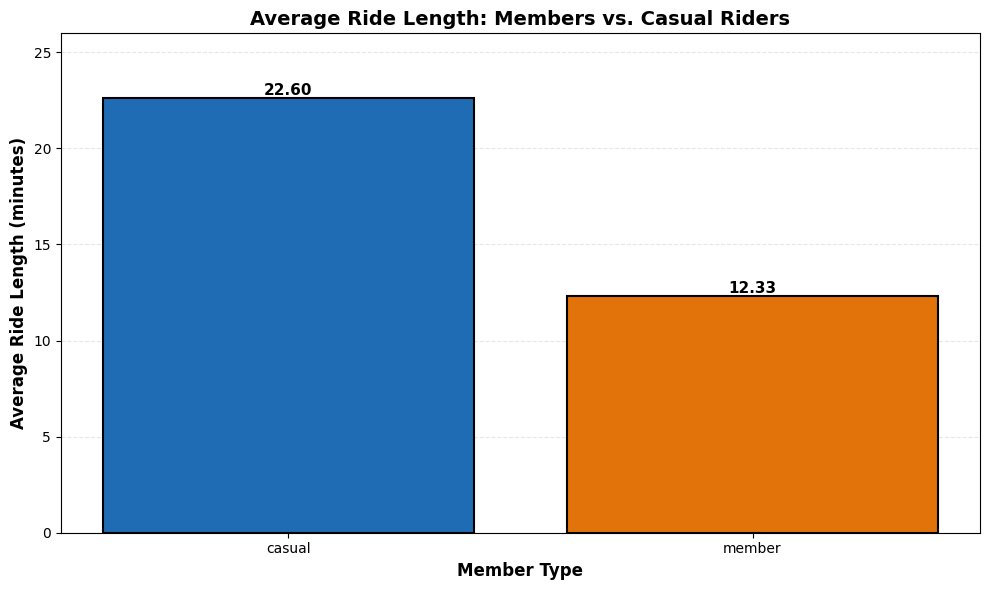

In [16]:
# Create a grouped bar chart for Average Ride Length by Member Type
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
member_types = avg_ride_length_by_member.index
avg_lengths = avg_ride_length_by_member.values
colors = ["#1f6cb4", "#E2730B"]

# Create bar chart
bars = ax.bar(member_types, avg_lengths, color=colors, edgecolor='black', linewidth=1.5)

# Customize the chart
ax.set_xlabel('Member Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Ride Length (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Average Ride Length: Members vs. Casual Riders', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(avg_lengths) * 1.15)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

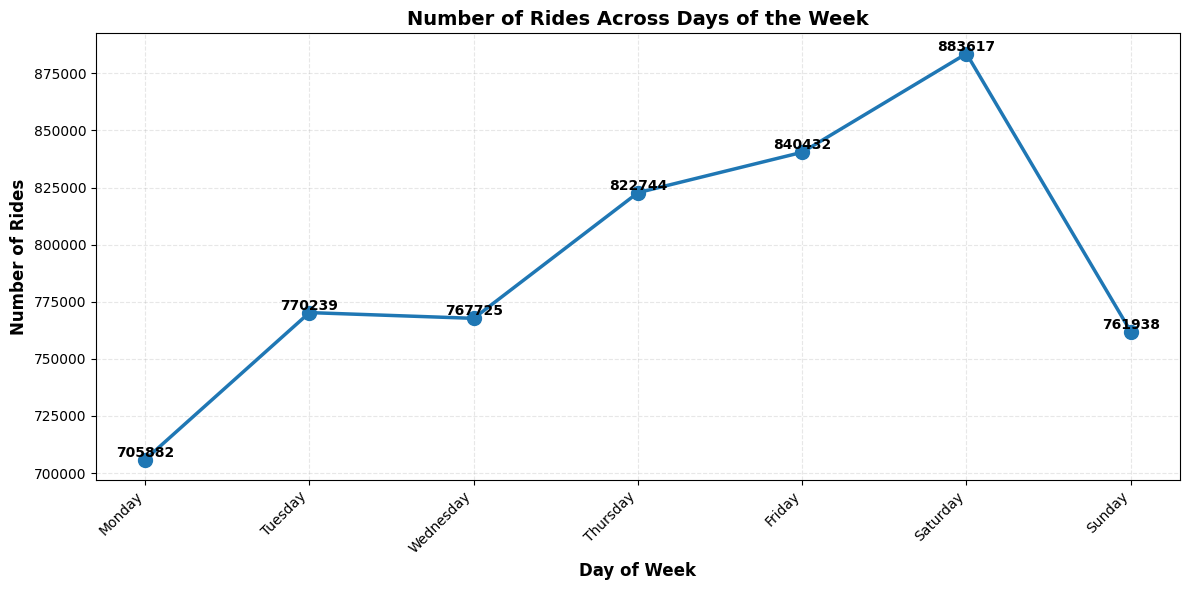

In [17]:
# Create a line graph for Number of Rides by Day of Week
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
days = rides_count_by_day.index
ride_counts = rides_count_by_day.values

# Create line graph
ax.plot(days, ride_counts, marker='o', linewidth=2.5, markersize=10, 
        color='#1f77b4', label='Rides Count')

# Customize the chart
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Rides', fontsize=12, fontweight='bold')
ax.set_title('Number of Rides Across Days of the Week', fontsize=14, fontweight='bold')

# Add value labels on each point
for i, (day, count) in enumerate(zip(days, ride_counts)):
    ax.text(i, count, f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

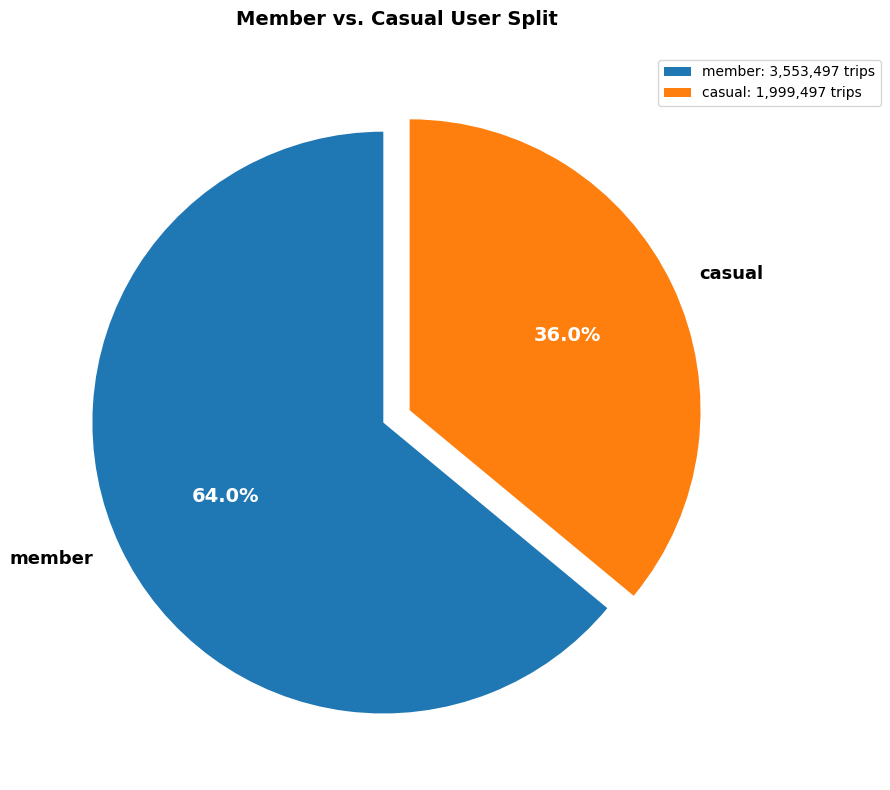

In [18]:
# Create a pie chart for Member vs Casual User Split
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data
user_types = member_percentage.index
percentages = member_percentage.values
colors = ['#1f77b4', '#ff7f0e']
explode = (0.05, 0.05)  # Slightly separate both slices

# Create pie chart
wedges, texts, autotexts = ax.pie(percentages, labels=user_types, autopct='%1.1f%%',
                                    colors=colors, explode=explode, startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

# Customize the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Customize labels
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Add title
ax.set_title('Member vs. Casual User Split', fontsize=14, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{user_type}: {member_distribution[user_type]:,} trips' 
                 for user_type in user_types]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(0.85, 0, 0.2, 1))

plt.tight_layout()
plt.show()


--- Rides by Day of Week and Member Type ---
member_casual  casual  member
weekday                      
Monday         229469  476413
Tuesday        219490  550749
Wednesday      218300  549425
Thursday       252305  570439
Friday         305626  534806
Saturday       413676  469941
Sunday         360416  401522


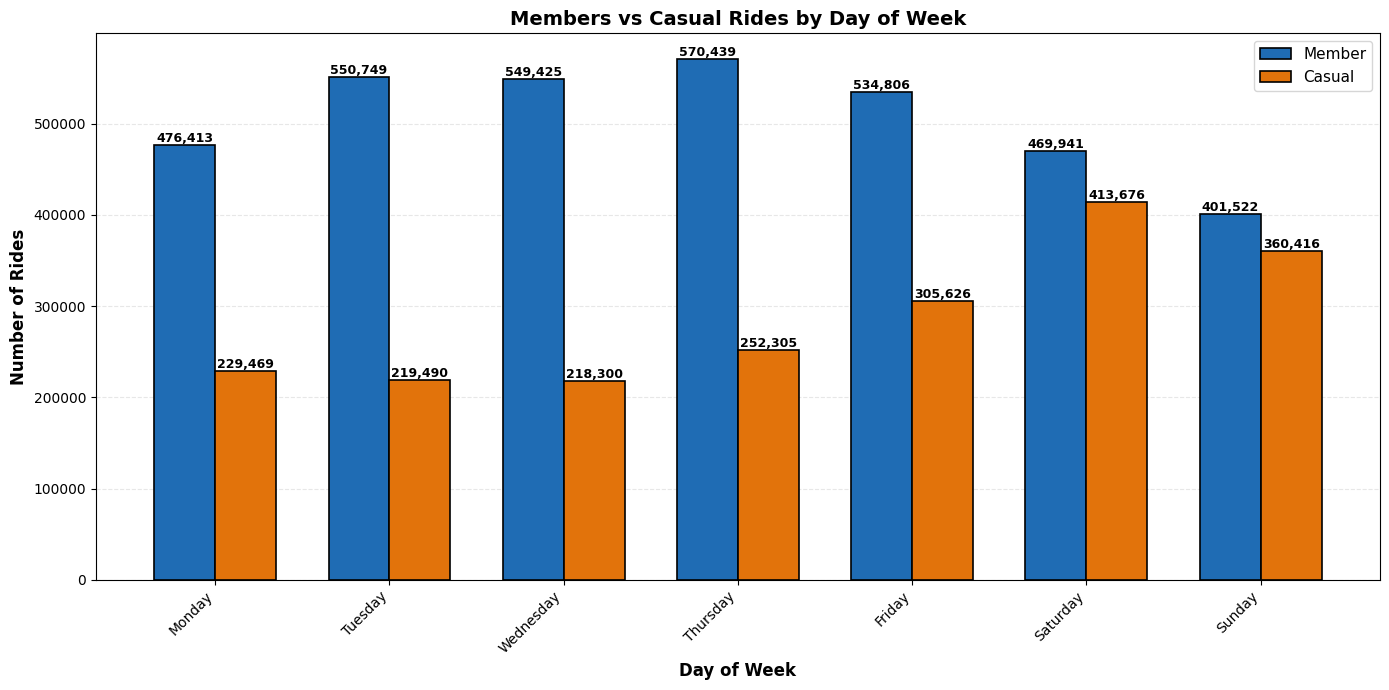


--- Summary Statistics ---
Total Member rides: 3,553,295
Total Casual rides: 1,999,282
Highest Member usage: Thursday (570,439 rides)
Highest Casual usage: Saturday (413,676 rides)


In [20]:
# Create a grouped bar chart for Members vs Casual Rides by Day of Week

# Group by weekday and member_casual, then count rides
rides_by_day_member = merged_df.groupby(['weekday', 'member_casual']).size().unstack(fill_value=0)

# Reorder by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rides_by_day_member = rides_by_day_member.reindex(day_order)

print("\n--- Rides by Day of Week and Member Type ---")
print(rides_by_day_member)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Set up bar positions
days = rides_by_day_member.index
x = np.arange(len(days))
width = 0.35

# Get member and casual data
member_data = rides_by_day_member['member']
casual_data = rides_by_day_member['casual']

# Create bars
bars1 = ax.bar(x - width/2, member_data, width, label='Member', color='#1f6cb4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, casual_data, width, label='Casual', color='#E2730B', edgecolor='black', linewidth=1.2)

# Customize chart
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Rides', fontsize=12, fontweight='bold')
ax.set_title('Members vs Casual Rides by Day of Week', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(days, rotation=45, ha='right')
ax.legend(fontsize=11)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\n--- Summary Statistics ---")
print(f"Total Member rides: {member_data.sum():,}")
print(f"Total Casual rides: {casual_data.sum():,}")
print(f"Highest Member usage: {member_data.idxmax()} ({member_data.max():,} rides)")
print(f"Highest Casual usage: {casual_data.idxmax()} ({casual_data.max():,} rides)")